In [52]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [53]:
from sklearn.datasets import load_iris
iris = load_iris()
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

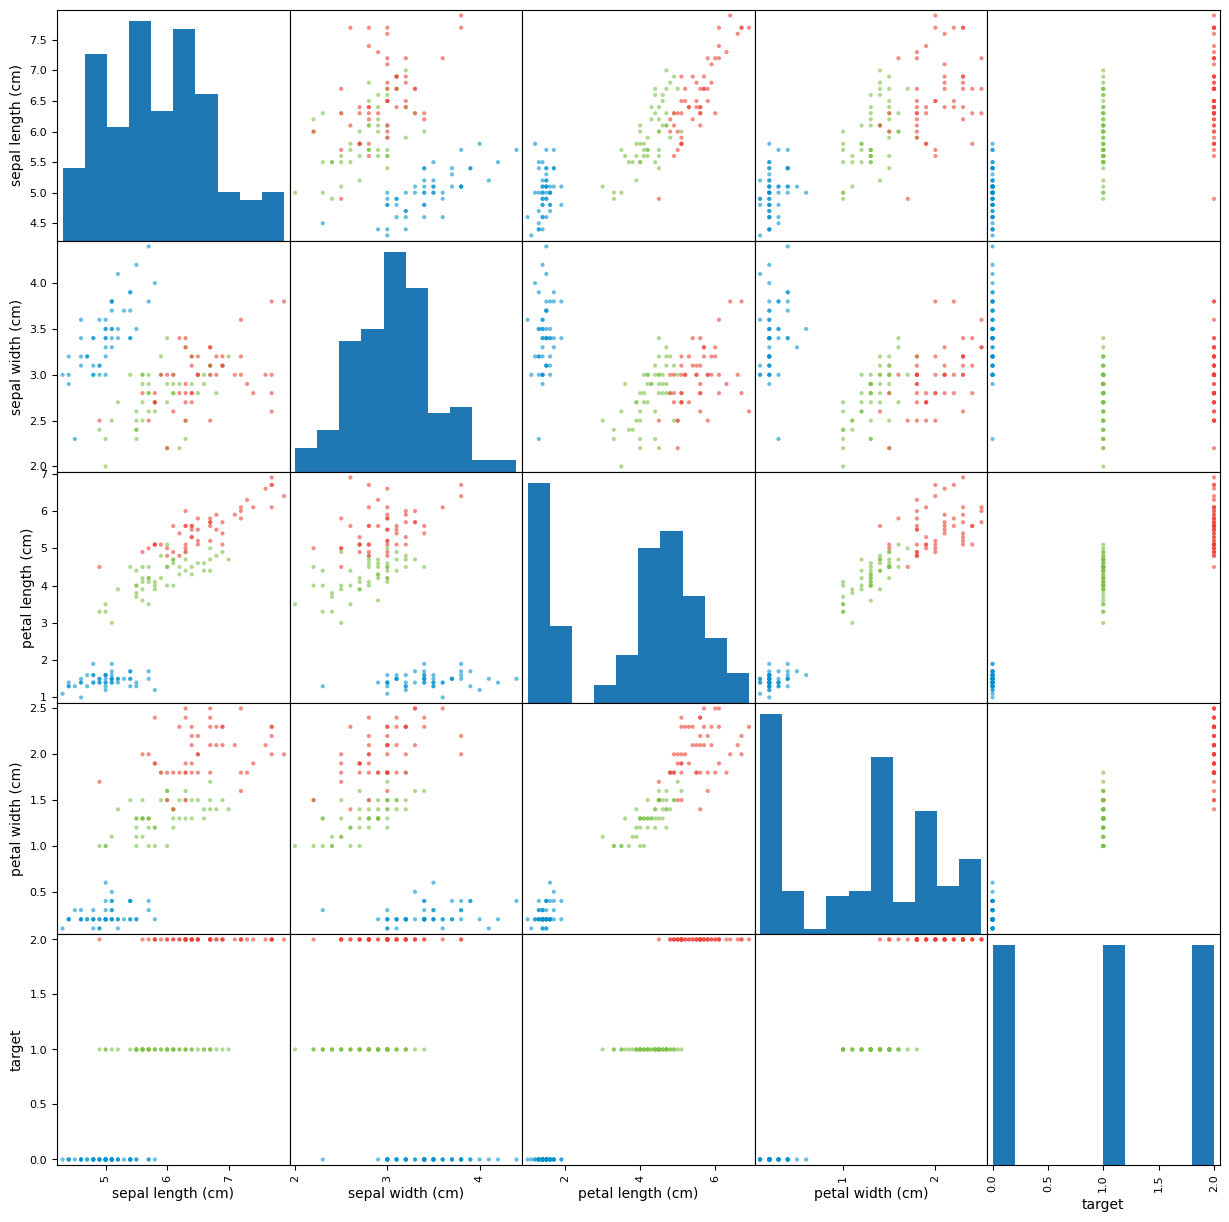

In [54]:
from pandas.plotting import scatter_matrix
import pandas as pd
iris_data = pd.DataFrame(data=iris['data'],columns=iris['feature_names'])
iris_data["target"] = iris['target']
color_wheel = {1: "#0392cf", 2: "#7bc043", 3: "#ee4035"}
colors = iris_data["target"].map(lambda x: color_wheel.get(x + 1))
ax = scatter_matrix(iris_data, color=colors, alpha=0.6, figsize=(15, 15))

In [55]:
# Select first 2 flower classes (~100 rows)
# And first 2 features
sepal_len = iris['data'][:100,0]
sepal_wid = iris['data'][:100,1]
labels = iris['target'][:100]
# We will also center the data
# This is done to make numbers nice, so that we have no
# need for biases in our classification. (You might not
# be able to remove biases this way in general.)
sepal_len -= np.mean(sepal_len)
sepal_wid -= np.mean(sepal_wid)

Text(0, 0.5, 'sepal width')

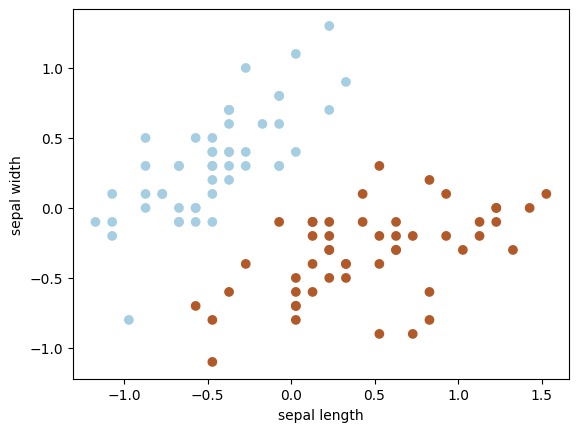

In [56]:
# Plot Iris
plt.scatter(sepal_len,sepal_wid,c=labels,cmap=plt.cm.Paired)
plt.xlabel("sepal length")
plt.ylabel("sepal width")

In [57]:
def plot_sep(w1, w2, color='green'):
  ''' Plot decision boundary hypothesis
  w1 * sepal_len + w2 * sepal_wid = 0
  in input space, highlighting the hyperplane '''
  plt.scatter(sepal_len,sepal_wid,c=labels,cmap=plt.cm.Paired)
  plt.title("Separation in Input Space")
  plt.ylim([-1.5,1.5])
  plt.xlim([-1.5,2])
  plt.xlabel("sepal length")
  plt.ylabel("sepal width")
  if w2 != 0:
     m = -w1/w2
     t = 1 if w2 > 0 else -1
     plt.plot([-1.5,2.0],[-1.5*m, 2.0*m],'-y',color=color)
     plt.fill_between(
                    [-1.5, 2.0],
                    [m*-1.5, m*2.0],
                    [t*1.5, t*1.5],
                    alpha=0.2,
                    color=color)
  if w2 == 0: # decision boundary is vertical
      t = 1 if w1 > 0 else -1
      plt.plot([0, 0],[-1.5, 2.0],'-y',color=color)
      plt.fill_between(
                    [0, 2.0*t],
                    [-1.5, -2.0],
                    [1.5, 2],
                    alpha=0.2,
                    color=color)

C:\Users\XGWang\AppData\Local\Temp\ipykernel_13444\545853458.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-y" (-> color='y'). The keyword argument will take precedence.
  plt.plot([-1.5,2.0],[-1.5*m, 2.0*m],'-y',color=color)


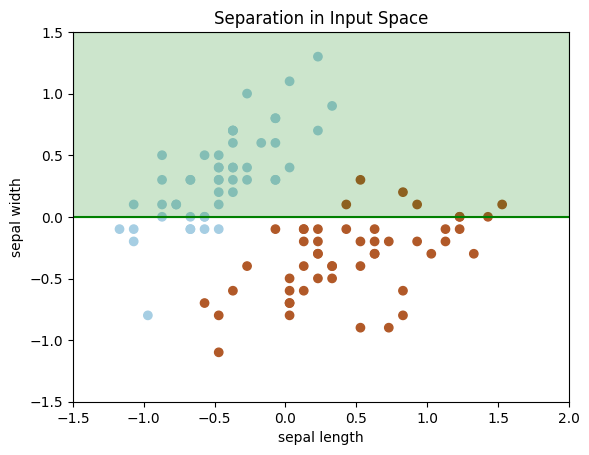

In [58]:
plot_sep(0, 1)

C:\Users\XGWang\AppData\Local\Temp\ipykernel_13444\545853458.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-y" (-> color='y'). The keyword argument will take precedence.
  plt.plot([-1.5,2.0],[-1.5*m, 2.0*m],'-y',color=color)


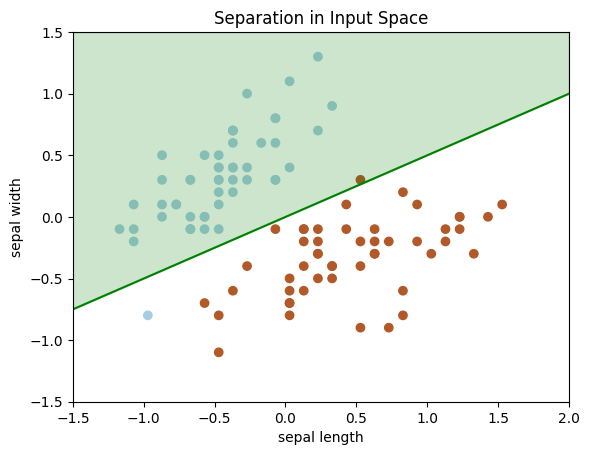

In [59]:
plot_sep(-0.5, 1)

-0.971000000000001 -0.7989999999999999


C:\Users\XGWang\AppData\Local\Temp\ipykernel_13444\545853458.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-y" (-> color='y'). The keyword argument will take precedence.
  plt.plot([-1.5,2.0],[-1.5*m, 2.0*m],'-y',color=color)


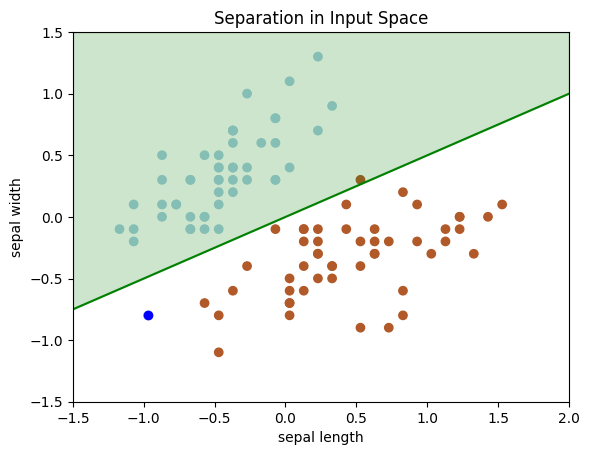

In [60]:
# We're going to hand pick one point and # analyze that point:
a1 = sepal_len[41]
a2 = sepal_wid[41]
print (a1, a2) # (-0.97, -0.79)
plot_sep(-0.5, 1)
plt.plot(a1, a2, 'ob') # highlight the point

In [61]:
# Now let's look at weight space
def plot_weight_space(sepal_len, sepal_wid, lab=1, color='steelblue',
                               maxlim=2.0):
  plt.title("Constraint(s) in Weight Space")
  plt.ylim([-maxlim,maxlim])
  plt.xlim([-maxlim,maxlim])
  plt.xlabel("w1")
  plt.ylabel("w2")
  if sepal_wid != 0:
    m = -sepal_len/sepal_wid
    t = 1*lab if sepal_wid > 0 else -1*lab
    plt.plot([-maxlim, maxlim],
                          [-maxlim*m, maxlim*m],
                          '-y',
                          color=color)
    plt.fill_between([-maxlim, maxlim], # x
                     [m*-maxlim, m*maxlim], # y-min
                     [t*maxlim, t*maxlim], # y-max alpha=0.2,
                     color=color)
  if sepal_wid == 0: # decision boundary is vertical
    t = 1*lab if sepal_len > 0 else -1*lab
    plt.plot([0, 0],[-maxlim, maxlim],'-y',color=color)
    plt.fill_between([0, 2.0*t],
                                           [-maxlim, -maxlim],
                                           [maxlim, maxlim],
                                           alpha=0.2,
                                           color=color)


-0.971000000000001 -0.7989999999999999


C:\Users\XGWang\AppData\Local\Temp\ipykernel_13444\643294086.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-y" (-> color='y'). The keyword argument will take precedence.
  plt.plot([-maxlim, maxlim],


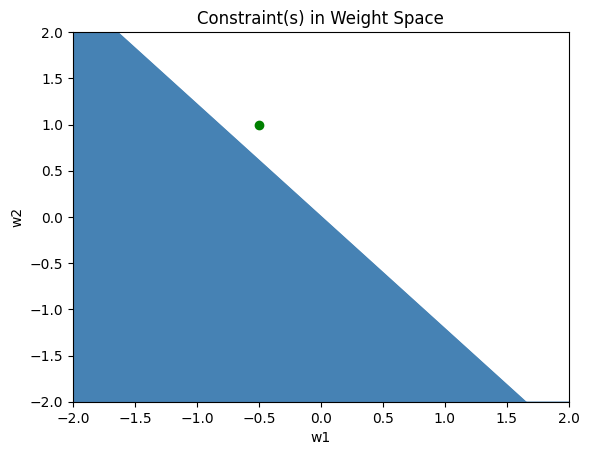

In [62]:
# Plot the constraint for the point identified earlier:
a1 = sepal_len[41]
a2 = sepal_wid[41]
print (a1, a2)
# Do this on the board first by hand
plot_weight_space(a1, a2, lab=1)
# Below is the hypothesis we plotted earlier
# Notice it falls outside the range.
plt.plot(-0.5, 1, 'og')

In [63]:
w1 = -0.5 # + ...
w2= 1 #+...


C:\Users\XGWang\AppData\Local\Temp\ipykernel_13444\643294086.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-y" (-> color='y'). The keyword argument will take precedence.
  plt.plot([-maxlim, maxlim],


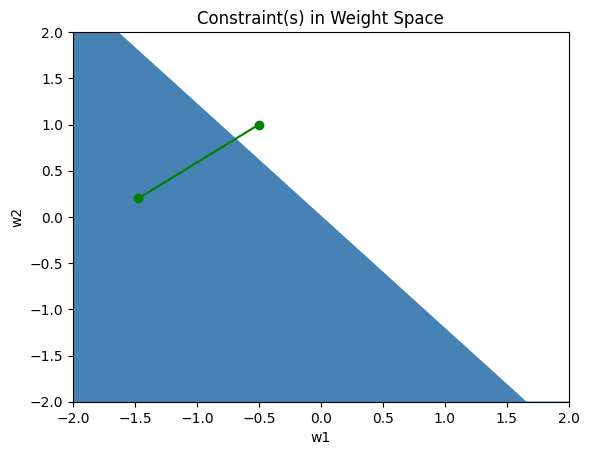

In [100]:
# This should bring the point closer to the boundary # In this case, the step brought the point into the # condition boundary
plot_weight_space(a1, a2, lab=1)
plt.plot(-0.5+a1, 1+a2, 'og')
# old hypothesis
plt.plot(-0.5, 1, 'og')
plt.plot([-0.5, -0.5+a1], [1, 1+a2], '-g')
#plt.axes().set_aspect('equal', 'box')

C:\Users\XGWang\AppData\Local\Temp\ipykernel_13444\545853458.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-y" (-> color='y'). The keyword argument will take precedence.
  plt.plot([-1.5,2.0],[-1.5*m, 2.0*m],'-y',color=color)


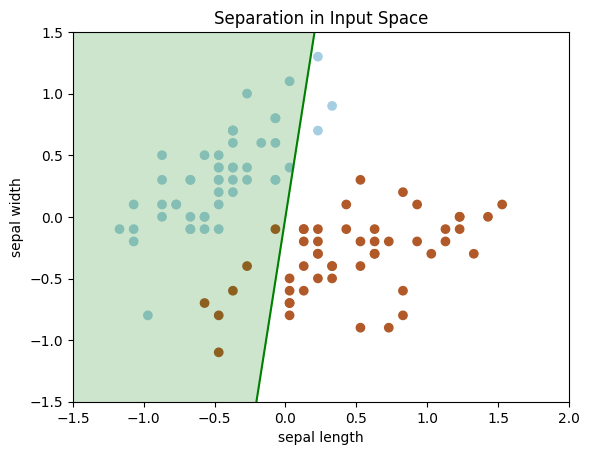

In [65]:
# Which means that the point (a1, a2) in input
# space is correctly classified.
plot_sep(-0.5+a1, 1+a2)

In [66]:
sepal_len

array([-0.371, -0.571, -0.771, -0.871, -0.471, -0.071, -0.871, -0.471,
       -1.071, -0.571, -0.071, -0.671, -0.671, -1.171,  0.329,  0.229,
       -0.071, -0.371,  0.229, -0.371, -0.071, -0.371, -0.871, -0.371,
       -0.671, -0.471, -0.471, -0.271, -0.271, -0.771, -0.671, -0.071,
       -0.271,  0.029, -0.571, -0.471,  0.029, -0.571, -1.071, -0.371,
       -0.471, -0.971, -1.071, -0.471, -0.371, -0.671, -0.371, -0.871,
       -0.171, -0.471,  1.529,  0.929,  1.429,  0.029,  1.029,  0.229,
        0.829, -0.571,  1.129, -0.271, -0.471,  0.429,  0.529,  0.629,
        0.129,  1.229,  0.129,  0.329,  0.729,  0.129,  0.429,  0.629,
        0.829,  0.629,  0.929,  1.129,  1.329,  1.229,  0.529,  0.229,
        0.029,  0.029,  0.329,  0.529, -0.071,  0.529,  1.229,  0.829,
        0.129,  0.029,  0.029,  0.629,  0.329, -0.471,  0.129,  0.229,
        0.229,  0.729, -0.371,  0.229])

In [67]:
sepal_wid

array([ 4.010e-01, -9.900e-02,  1.010e-01,  1.000e-03,  5.010e-01,
        8.010e-01,  3.010e-01,  3.010e-01, -1.990e-01,  1.000e-03,
        6.010e-01,  3.010e-01, -9.900e-02, -9.900e-02,  9.010e-01,
        1.301e+00,  8.010e-01,  4.010e-01,  7.010e-01,  7.010e-01,
        3.010e-01,  6.010e-01,  5.010e-01,  2.010e-01,  3.010e-01,
       -9.900e-02,  3.010e-01,  4.010e-01,  3.010e-01,  1.010e-01,
        1.000e-03,  3.010e-01,  1.001e+00,  1.101e+00,  1.000e-03,
        1.010e-01,  4.010e-01,  5.010e-01, -9.900e-02,  3.010e-01,
        4.010e-01, -7.990e-01,  1.010e-01,  4.010e-01,  7.010e-01,
       -9.900e-02,  7.010e-01,  1.010e-01,  6.010e-01,  2.010e-01,
        1.010e-01,  1.010e-01,  1.000e-03, -7.990e-01, -2.990e-01,
       -2.990e-01,  2.010e-01, -6.990e-01, -1.990e-01, -3.990e-01,
       -1.099e+00, -9.900e-02, -8.990e-01, -1.990e-01, -1.990e-01,
        1.000e-03, -9.900e-02, -3.990e-01, -8.990e-01, -5.990e-01,
        1.010e-01, -2.990e-01, -5.990e-01, -2.990e-01, -1.990e

In [68]:
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [69]:
sgn_labels=labels.copy()

In [70]:
sgn_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [71]:
for i in range(0,sgn_labels.size,1):
  if sgn_labels[i] == 0:
    sgn_labels[i]=-1

In [72]:
sgn_labels

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [73]:
def plr2d(x1,x2,t,w0_0,w1_0,w2_0,N,disable_w0):
  w0=w0_0
  w1=w1_0
  w2=w2_0
  for n in range(0,N,1):
    mismatched = False
    for i in range(0,t.size,1):
      z=w0 + x1[i]*w1 + x2[i]*w2
      if z*(t[i]) <= 0:
        mismatched = True
        if disable_w0:
          w0 = w0
        else:
          w0 = w0 + (t[i])*1
        w1 = w1 + (t[i])*(x1[i])
        w2 = w2 + (t[i])*(x2[i])
    if mismatched == False:
      print("converged: n=",n)
      break
  print("learning done")
  cnt=0
  for i in range(0,t.size,1):
      z=w0 + x1[i]*w1 + x2[i]*w2
      if z*(t[i]) <= 0:
        print("mismatch[",i,"]")
        cnt+=1
  print(cnt,"mismatches")
  return [w0,w1,w2]

C:\Users\XGWang\AppData\Local\Temp\ipykernel_13444\545853458.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-y" (-> color='y'). The keyword argument will take precedence.
  plt.plot([-1.5,2.0],[-1.5*m, 2.0*m],'-y',color=color)


converged: n= 1
learning done
0 mismatches
[0, 0.37100000000000133, -0.40100000000000025]


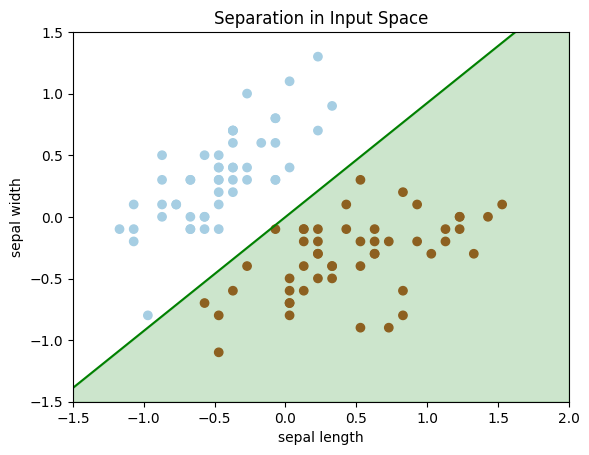

In [74]:
[wt0,wt1,wt2]=plr2d(sepal_len,sepal_wid,sgn_labels,0,0,0,10,True)
print([wt0,wt1,wt2])
plot_sep(wt1,wt2)

In [75]:
# reference AND
x1=np.array([0,0,1,1])
x2=np.array([0,1,0,1])
t=np.array([-1,-1,-1,1])
[w0,w1,w2]=plr2d(x1,x2,t,0,0,0,100,False)
print([w0,w1,w2])

converged: n= 8
learning done
0 mismatches
[-4, 3, 2]


In [76]:
# reference OR
x1=np.array([0,0,1,1])
x2=np.array([0,1,0,1])
t=np.array([-1,1,1,1])
[w0,w1,w2]=plr2d(x1,x2,t,0,0,0,100,False)
print([w0,w1,w2])

converged: n= 5
learning done
0 mismatches
[-1, 2, 2]


In [77]:
# reference NOT
x1=np.array([1,1])
x2=np.array([0,1])
t=np.array([1,-1])
[w0,w1,w2]=plr2d(x1,x2,t,0,0,0,100,False)
print([w0,w1,w2])

converged: n= 4
learning done
0 mismatches
[1, 1, -3]


In [78]:
import sklearn as sklearn

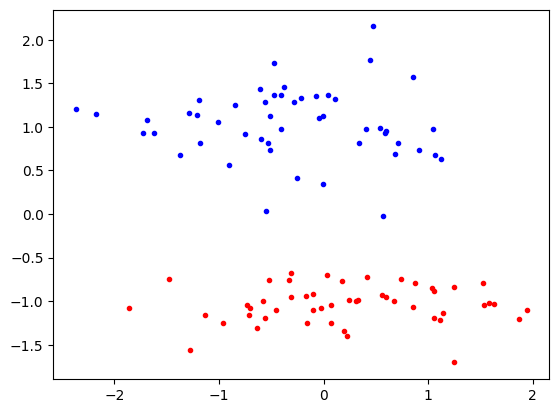

In [80]:
# generate a separable DS
import sklearn 
separable = False
while not separable:
    samples = sklearn.datasets.make_classification(n_samples=100, n_features=2, n_redundant=0, n_informative=1, n_clusters_per_class=1, flip_y=0)
    red = samples[0][samples[1] == 0]
    blue = samples[0][samples[1] == 1]
    separable = any([red[:, k].max() < blue[:, k].min() or red[:, k].min() > blue[:, k].max() for k in range(2)])
plt.plot(red[:, 0], red[:, 1], 'r.')
plt.plot(blue[:, 0], blue[:, 1], 'b.')
plt.show()

In [102]:
x1 = samples[0][:100,0]
x2 = samples[0][:100,1]
labels = samples[1]
sgn_labels=labels.copy()
for i in range(0,sgn_labels.size,1):
  if sgn_labels[i] == 0:
    sgn_labels[i]=-1

#plt.scatter(x1,x2,c=labels,cmap=plt.cm.Paired)


converged: n= 1
learning done
0 mismatches
1 -0.020451060974848834 1.6112531822616034


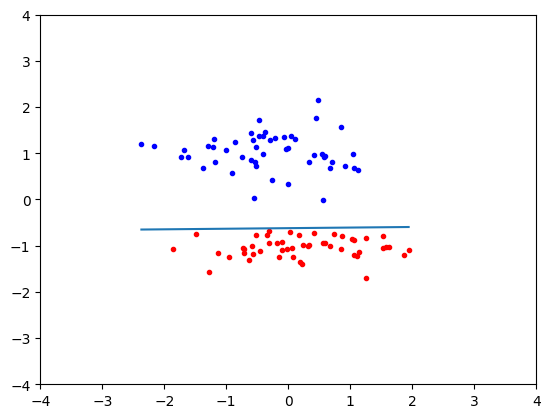

In [82]:
[w0,w1,w2]=plr2d(x1,x2,sgn_labels,0,0,0,100,False)
print(w0,w1,w2)

red = samples[0][samples[1] == 0]
blue = samples[0][samples[1] == 1]
separable = any([red[:, k].max() < blue[:, k].min() or red[:, k].min() > blue[:, k].max() for k in range(2)])
plt.plot(red[:, 0], red[:, 1], 'r.')
plt.plot(blue[:, 0], blue[:, 1], 'b.')
plt.ylim([-4,4])
plt.xlim([-4,4])
x_values = [np.min(x1[:]), np.max(x1[:])]
y_values = np.dot((-1./w2), (np.dot(w1,x_values) + w0))
plt.plot(x_values, y_values, label='Decision Boundary')
plt.show()

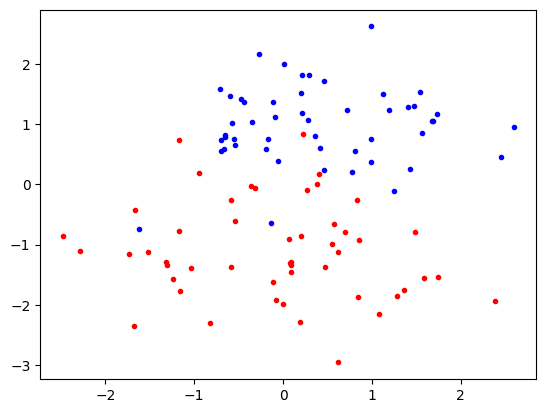

In [87]:
# generate a NON separable DS
separable = True
while separable:
    samples = sklearn.datasets.make_classification(n_samples=100, n_features=2, n_redundant=0, n_informative=1, n_clusters_per_class=1, flip_y=0)
    red = samples[0][samples[1] == 0]
    blue = samples[0][samples[1] == 1]
    separable = any([red[:, k].max() < blue[:, k].min() or red[:, k].min() > blue[:, k].max() for k in range(2)])
plt.plot(red[:, 0], red[:, 1], 'r.')
plt.plot(blue[:, 0], blue[:, 1], 'b.')
plt.show()

In [88]:
x1 = samples[0][:100,0]
x2 = samples[0][:100,1]
labels = samples[1]
sgn_labels=labels.copy()
for i in range(0,sgn_labels.size,1):
  if sgn_labels[i] == 0:
    sgn_labels[i]=-1

#plt.scatter(x1,x2,c=labels,cmap=plt.cm.Paired)


learning done
mismatch[ 11 ]
mismatch[ 26 ]
mismatch[ 65 ]
mismatch[ 75 ]
mismatch[ 82 ]
mismatch[ 84 ]
mismatch[ 92 ]
7 mismatches
0 0.2386381268368536 1.5491313565561005


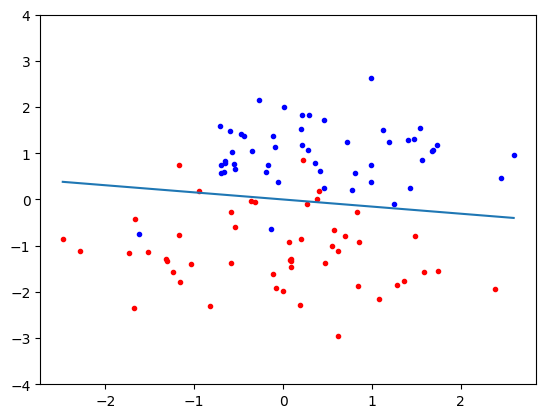

In [89]:
# ignore w0 (disable set to True)
[w0,w1,w2]=plr2d(x1,x2,sgn_labels,0,0,0,100,False)
print(w0,w1,w2)
#plot_ds(w1,w2,x1,x2)
red = samples[0][samples[1] == 0]
blue = samples[0][samples[1] == 1]
separable = any([red[:, k].max() < blue[:, k].min() or red[:, k].min() > blue[:, k].max() for k in range(2)])
plt.plot(red[:, 0], red[:, 1], 'r.')
plt.plot(blue[:, 0], blue[:, 1], 'b.')
plt.ylim([-4,4])
#plt.xlim([-4,4])
x_values = [np.min(x1[:]), np.max(x1[:])]
y_values = np.dot((-1./w2), (np.dot(w1,x_values) + w0))
plt.plot(x_values, y_values, label='Decision Boundary')
plt.show()
# note this doesn't converge (it breaks due to limIter) and produces classifier that missing many cases

In [90]:
import numpy as np

In [91]:
def ptrLCE_ERROR(x1,x2,t,w0_0,w1_0,w2_0,N,disable_w0,alpha):
  w0=w0_0
  w1=w1_0
  w2=w2_0
  for n in range(0,N,1):
    for i in range(0,t.size,1):
      z=w0 + x1[i]*w1 + x2[i]*w2
      #print(n,z)
      y=1./(1+np.exp(-z))
      # A. dL/dz = y - t
      # B1. dL/db = dL/dz
      if disable_w0:
        w0 = w0_0
      else:
         w0 = w0 - alpha*(y-t[i])
      # B2. dL/dwi = dL/dz*xi
      w1 = w1 - alpha*(y-t[i])*x1[i]
      w2 = w2 - alpha*(y-t[i])*x2[i]
  cnt=0
  for i in range(0,t.size,1):
      z=w0 + x1[i]*w1 + x2[i]*w2
      y=1./(1+np.exp(-z))
      if y < 0.5:
        c=0
      else:
        c=1

      if c!=t[i]:
        print("mismatch[",i,"]",c,t[i])
        cnt+=1
  print(cnt,"mismatches")
  return [w0,w1,w2]

In [103]:
def ptrLCE(x1,x2,t,w0_0,w1_0,w2_0,disable_w0,alpha):
  w0=w0_0
  w1=w1_0
  w2=w2_0
  gradEw=0
  gradEb=0

  for i in range(0,t.size,1):
    z=w0 + x1[i]*w1 + x2[i]*w2
    y=1./(1+np.exp(-z))
    gradEw += np.array([x1[i],x2[i]])*(y-t[i])
    gradEb += (y-t[i])
  gradEw = gradEw/t.size
  gradEb = gradEb/t.size
  # A. dL/dz = y - t
  # B1. dL/db = dL/dz
  if disable_w0:
    w0 = w0_0
  else:
    w0 = w0 - alpha*gradEb
  # B2. dL/dwi = dL/dz*xi
  w1 = w1 - alpha*gradEw[0]
  w2 = w2 - alpha*gradEw[1]
  cnt=0
  for i in range(0,t.size,1):
      z=w0 + x1[i]*w1 + x2[i]*w2
      y=1./(1+np.exp(-z))
      if y < 0.5:
        c=0
      else:
        c=1

      if c!=t[i]:
        print("mismatch[",i,"]",c,t[i])
        cnt+=1
  print(cnt,"mismatches")
  return [w0,w1,w2]

mismatch[ 11 ] 1 0
mismatch[ 26 ] 0 1
mismatch[ 65 ] 1 0
mismatch[ 75 ] 1 0
mismatch[ 82 ] 1 0
mismatch[ 92 ] 0 1
6 mismatches
0.0 0.00012059098819948745 0.0005222469914001061


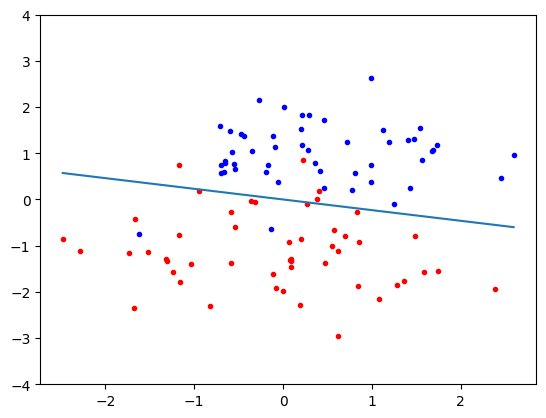

In [104]:
[w0,w1,w2]=ptrLCE(x1,x2,labels,0,0,0,False,0.001)
print(w0,w1,w2)

red = samples[0][samples[1] == 0]
blue = samples[0][samples[1] == 1]
separable = any([red[:, k].max() < blue[:, k].min() or red[:, k].min() > blue[:, k].max() for k in range(2)])
plt.plot(red[:, 0], red[:, 1], 'r.')
plt.plot(blue[:, 0], blue[:, 1], 'b.')
plt.ylim([-4,4])
#plt.xlim([-4,4])
x_values = [np.min(x1[:]), np.max(x1[:])]
y_values = np.dot((-1./w2), (np.dot(w1,x_values) + w0))
plt.plot(x_values, y_values, label='Decision Boundary')
plt.show()

In [105]:
class SoftmaxMCLR(object):
    
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.y_onehot = self.onehot_encoded(y)
        self.w = np.zeros([X.shape[1],len(np.unique(y))])
        self.w0 = np.zeros(np.unique(y).shape[0])
        self.N = X.shape[0]

        
    def softmax(self, z):
        # elements are shifted with np.max(X) to avoid numerical overshoot
        z -= np.max(z)
        s = (np.exp(z).T / np.sum(np.exp(z),axis=1)).T
        return s
    
    
    def onehot_encoded(self, y):
        return (np.arange(np.max(y) + 1) == self.y[:, None]).astype(float)
    
    def probs(self, X):
        
        return self.softmax(np.dot(X, self.w) + self.w0)
    
    def predict(self, X):
        
        return np.argmax(self.probs(X), axis=1)
    
    def calc_grad_loss(self):
        probs = self.probs(self.X)
        loss = (-1 / self.N) * np.sum(self.y_onehot * np.log(probs))
        grad = (-1 / self.N) * np.dot(self.X.T, (self.y_onehot - probs))
        gradw0 = (-1 / self.N) * np.sum(self.y_onehot - probs)
        
        return loss, grad, gradw0

    
    def fit(self, learning_rate, iterations):
        
        losses = []
        
        for i in range(0, iterations):
            
                loss, grad, gradw0 = self.calc_grad_loss()
                losses.append(loss)
                self.w = self.w - (learning_rate * grad)
                
                self.w0 = self.w0 - (learning_rate * gradw0)
                
        preds = self.predict(self.X)
        corr = 0
        for i, pred in enumerate(preds):
            if pred == self.y_onehot[i].argmax():
                corr +=1 
            accuracy = corr / float(len(self.y))
            
        print('final loss: ',loss)
        print('accuracy on the training set: {} % '.format(accuracy * 100))
        print()
        plt.figure()
        plt.ylabel('loss')
        plt.xlabel('iteration')
        plt.plot(losses)
            

array([1, 0, 1, 0, 0, 0, 2, 2, 1, 0, 0, 0, 1, 0, 2, 1, 2, 0, 2, 2, 2, 2,
       2, 0, 1, 1, 1, 1, 2, 2, 0, 1, 1, 0, 2, 2, 0, 1, 1, 2, 2, 1, 1, 0,
       0, 0, 1, 1, 2, 2, 2, 1, 0, 1, 2, 2, 1, 1, 0, 1, 1, 2, 2, 2, 2, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 1, 0, 0, 0, 2, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 2, 2, 2, 2, 0, 0, 2, 2])

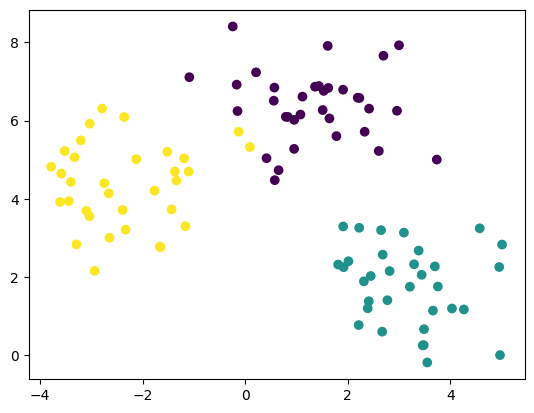

In [95]:
# Generate some data with 3 features
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=0, center_box=(-15,15))
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y)
y

In [126]:
sm_reg = SoftmaxMCLR(X, y)

final loss:  0.12005926133221902
accuracy on the training set: 95.0 % 



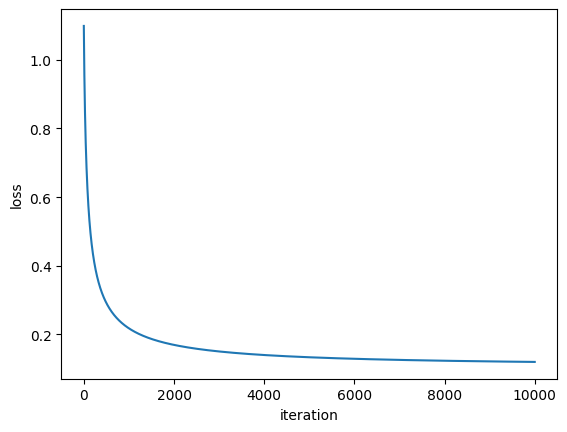

In [127]:
sm_reg.fit(learning_rate=0.005, iterations=10000)

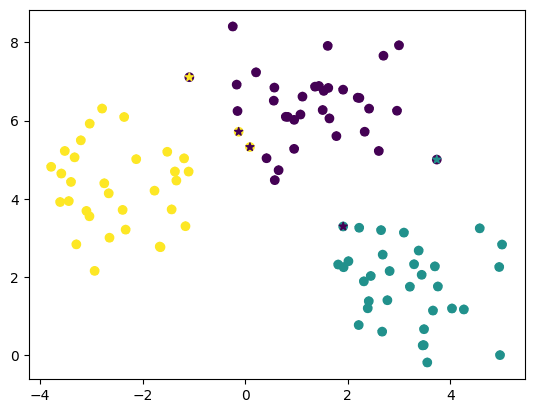

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.scatter(X[:, 0], X[:, 1], c=sm_reg.predict(X),marker='*')
